# 🌿 Smart Farming AI — Data Exploration
**PlantVillage Dataset — 54,305 images, 38 disease classes**

Run cells **top to bottom**. Cell 1 must always run first.

In [43]:
# ============================================================
# CELL 1 — Fix working directory (ALWAYS run this first)
# ============================================================
import os

os.chdir('/Users/ankitkumar/Desktop/script/pr')
print('📍 Working directory:', os.getcwd())
print('\n📂 Project contents:')
for item in sorted(os.listdir('.')):
    if not item.startswith('.'):
        print(' ', item)

📍 Working directory: /Users/ankitkumar/Desktop/script/pr

📂 Project contents:
  api
  data
  frontend
  models
  notebooks
  requ.txt
  src
  venv


In [44]:
# ============================================================
# CELL 2 — List all 38 classes with image counts
# ============================================================
import os

data_dir = 'data/raw/color'

classes = [c for c in sorted(os.listdir(data_dir))
           if not c.startswith('.')]

print(f'✅ Total classes: {len(classes)}')
print(f'\n📂 All disease classes:\n')

total_images = 0
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    count = len([f for f in os.listdir(cls_path)
                 if not f.startswith('.')])
    total_images += count
    print(f'  {cls[:50]:<50} → {count} images')

print(f'\n📊 Total images: {total_images}')

✅ Total classes: 38

📂 All disease classes:

  Apple___Apple_scab                                 → 630 images
  Apple___Black_rot                                  → 621 images
  Apple___Cedar_apple_rust                           → 275 images
  Apple___healthy                                    → 1645 images
  Blueberry___healthy                                → 1502 images
  Cherry_(including_sour)___Powdery_mildew           → 1052 images
  Cherry_(including_sour)___healthy                  → 854 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → 513 images
  Corn_(maize)___Common_rust_                        → 1192 images
  Corn_(maize)___Northern_Leaf_Blight                → 985 images
  Corn_(maize)___healthy                             → 1162 images
  Grape___Black_rot                                  → 1180 images
  Grape___Esca_(Black_Measles)                       → 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)         → 1076 images
  Grape___healthy      

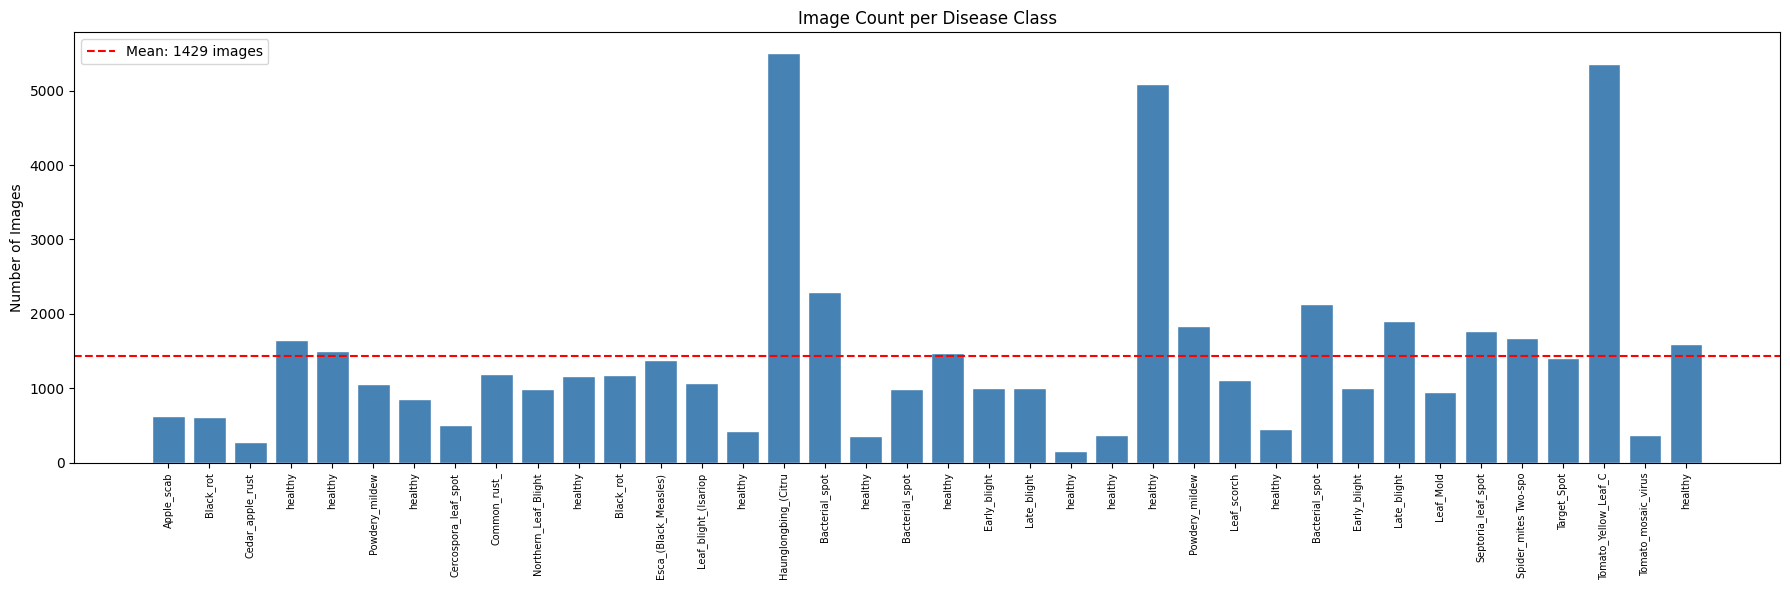

Min: 152 | Max: 5507 | Mean: 1429
Most images : Orange___Haunglongbing_(Citrus_greening) (5507)
Least images: Potato___healthy (152)


In [45]:
# ============================================================
# CELL 3 — Class imbalance bar chart
# ============================================================
import os
import matplotlib.pyplot as plt

data_dir = 'data/raw/color'
classes = [c for c in sorted(os.listdir(data_dir)) if not c.startswith('.')]

counts = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    count = len([f for f in os.listdir(cls_path) if not f.startswith('.')])
    counts.append(count)

short_names = [c.split('___')[-1][:20] for c in classes]

plt.figure(figsize=(18, 6))
plt.bar(range(len(classes)), counts, color='steelblue', edgecolor='white')
plt.xticks(range(len(classes)), short_names, rotation=90, fontsize=7)
plt.ylabel('Number of Images')
plt.title('Image Count per Disease Class')
plt.axhline(y=sum(counts)/len(counts), color='red', linestyle='--',
            label=f'Mean: {sum(counts)//len(counts)} images')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Min: {min(counts)} | Max: {max(counts)} | Mean: {sum(counts)//len(counts)}')
print(f'Most images : {classes[counts.index(max(counts))]} ({max(counts)})')
print(f'Least images: {classes[counts.index(min(counts))]} ({min(counts)})')

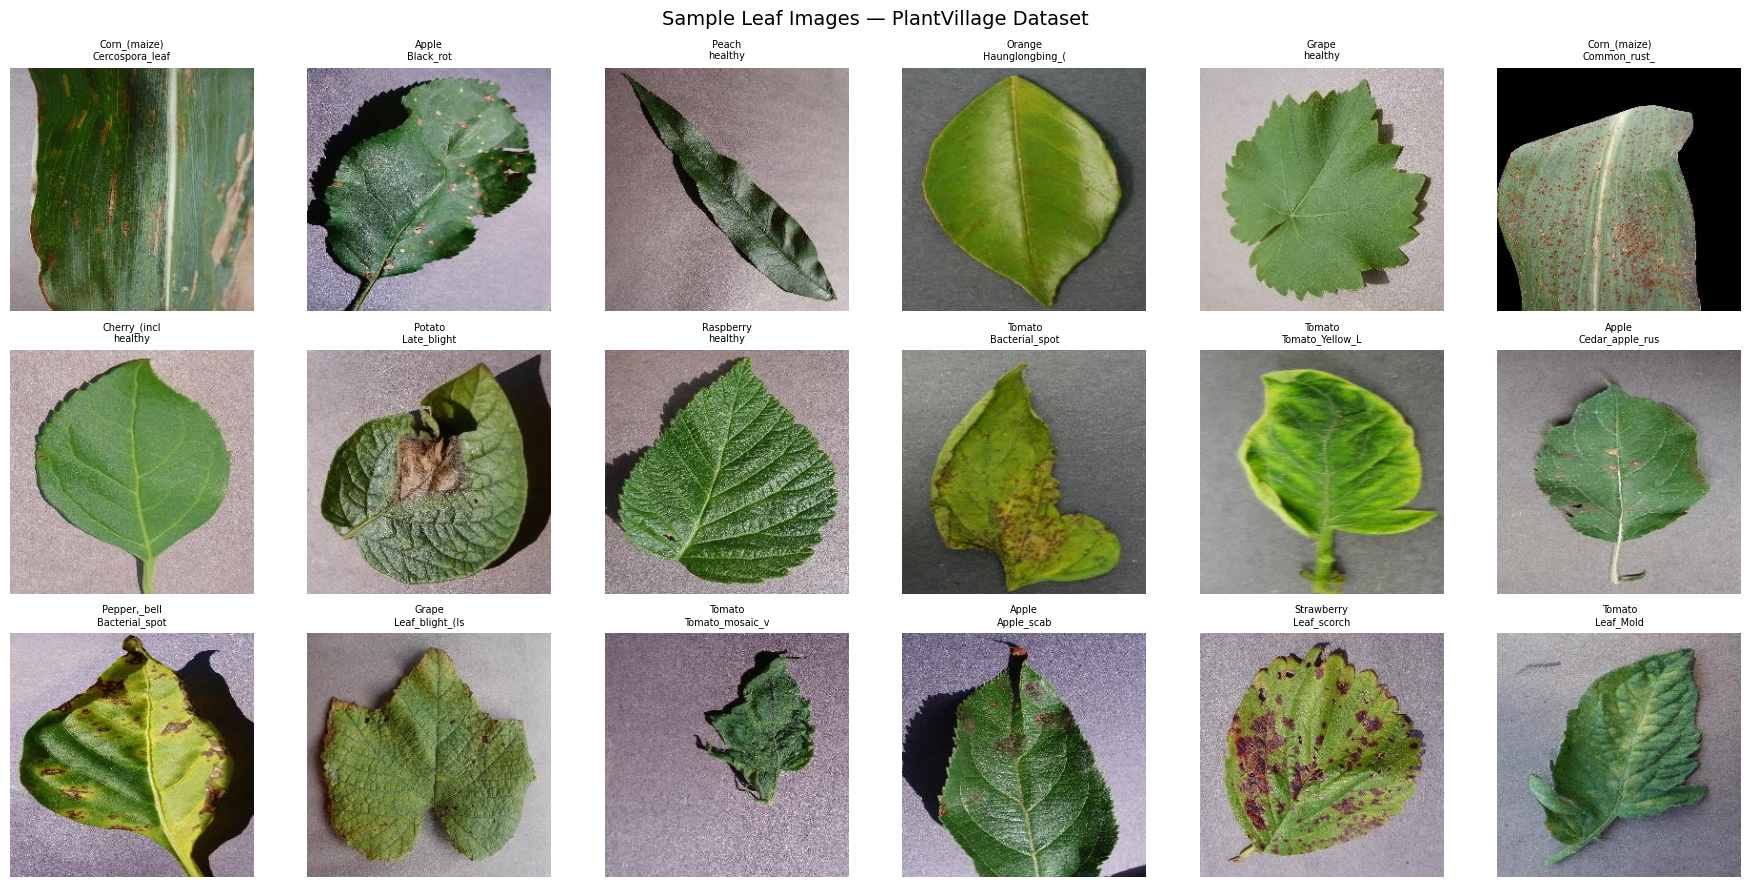

In [46]:
# ============================================================
# CELL 4 — Visualize sample leaf images (3x6 grid)
# ============================================================
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

data_dir = 'data/raw/color'
classes = [c for c in sorted(os.listdir(data_dir)) if not c.startswith('.')]

random.seed(42)
sample_classes = random.sample(classes, 18)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(data_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    img_path = os.path.join(cls_path, random.choice(img_files))
    img = Image.open(img_path)
    axes[i].imshow(img)
    parts = cls.split('___')
    title = f"{parts[0][:12]}\n{parts[1][:15]}" if len(parts) > 1 else cls[:20]
    axes[i].set_title(title, fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Leaf Images — PlantVillage Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# CELL 5 — Check image sizes and color modes
# ============================================================
import os
import random
from PIL import Image
from collections import Counter

data_dir = 'data/raw/color'
classes = [c for c in sorted(os.listdir(data_dir)) if not c.startswith('.')]

all_images = []
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path)
            if not f.startswith('.')]
    all_images.extend(imgs)

random.seed(42)
sample = random.sample(all_images, 200)

sizes, modes = [], []
for img_path in sample:
    with Image.open(img_path) as img:
        sizes.append(img.size)
        modes.append(img.mode)

print('📐 Image sizes (top 5):')
for size, count in Counter(sizes).most_common(5):
    print(f'   {size} → {count} images')

print(f'\n🎨 Color modes:')
for mode, count in Counter(modes).items():
    print(f'   {mode} → {count} images')

📐 Image sizes (top 5):
   (256, 256) → 200 images

🎨 Color modes:
   RGB → 200 images


In [48]:
# ============================================================
# CELL 6 — Split dataset into train / val / test
# Skips automatically if already done
# ============================================================
import os
import shutil
import random

data_dir     = 'data/raw/color'
processed    = 'data/processed'
classes      = [c for c in sorted(os.listdir(data_dir)) if not c.startswith('.')]
train_path   = os.path.join(processed, 'train')

# Skip if already split
if os.path.exists(train_path) and len(os.listdir(train_path)) == 38:
    print('✅ Already split — skipping.')
else:
    print('⏳ Splitting dataset (1-2 mins)...')
    random.seed(42)
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        images   = [f for f in os.listdir(cls_path) if not f.startswith('.')]
        random.shuffle(images)
        n        = len(images)
        n_train  = int(n * 0.70)
        n_val    = int(n * 0.15)
        splits   = {
            'train': images[:n_train],
            'val'  : images[n_train:n_train + n_val],
            'test' : images[n_train + n_val:]
        }
        for split, files in splits.items():
            out = os.path.join(processed, split, cls)
            os.makedirs(out, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(cls_path, f), os.path.join(out, f))

print()
for split in ['train', 'val', 'test']:
    sp = os.path.join(processed, split)
    total = sum(len(os.listdir(os.path.join(sp, c)))
                for c in os.listdir(sp) if not c.startswith('.'))
    print(f'  {split:<6}: {total} images')

✅ Already split — skipping.

  train : 37997 images
  val   : 8129 images
  test  : 8179 images


In [49]:
# ============================================================
# CELL 7 — Save class names to models/class_names.json
# ============================================================
import os
import json

data_dir    = 'data/raw/color'
class_names = sorted([c for c in os.listdir(data_dir) if not c.startswith('.')])

os.makedirs('models', exist_ok=True)
save_path = 'models/class_names.json'

with open(save_path, 'w') as f:
    json.dump(class_names, f, indent=2)

print(f'✅ Saved {len(class_names)} class names → {save_path}')
print(f'\nFirst 5 : {class_names[:5]}')
print(f'Last  5 : {class_names[-5:]}')

✅ Saved 38 class names → models/class_names.json

First 5 : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
Last  5 : ['Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [50]:
# ============================================================
# CELL 8 — Check PyTorch + MPS (Mac GPU)
# ============================================================
import torch

print('PyTorch version :', torch.__version__)
print('MPS available   :', torch.backends.mps.is_available())
print('MPS built       :', torch.backends.mps.is_built())

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('\n✅ Using device  :', device)

# Quick sanity test
x = torch.randn(3, 3).to(device)
print('\nTest tensor on', str(device), '\n', x)

PyTorch version : 2.12.0
MPS available   : True
MPS built       : True

✅ Using device  : mps

Test tensor on mps 
 tensor([[-1.1530, -1.1165,  1.1806],
        [-0.6025,  0.0863,  1.2368],
        [ 0.4346,  1.4648, -0.8420]], device='mps:0')


In [51]:
# ============================================================
# CELL 9 — Final checklist
# ============================================================
import os, json, torch

print('=' * 52)
print('   EXPLORATION COMPLETE — Checklist')
print('=' * 52)

checks = {
    'data/raw/color exists'          : os.path.exists('data/raw/color'),
    'data/processed/train exists'    : os.path.exists('data/processed/train'),
    'data/processed/val exists'      : os.path.exists('data/processed/val'),
    'data/processed/test exists'     : os.path.exists('data/processed/test'),
    'models/class_names.json exists' : os.path.exists('models/class_names.json'),
    'PyTorch installed'              : True,
    'MPS (Apple GPU) available'      : torch.backends.mps.is_available(),
}

all_ok = True
for label, status in checks.items():
    icon = '✅' if status else '❌'
    print(f'  {icon}  {label}')
    if not status:
        all_ok = False

print('=' * 52)
if all_ok:
    print('  🚀 All good! Next → run src/train.py')
else:
    print('  ⚠️  Fix the ❌ items above before training')
print('=' * 52)

   EXPLORATION COMPLETE — Checklist
  ✅  data/raw/color exists
  ✅  data/processed/train exists
  ✅  data/processed/val exists
  ✅  data/processed/test exists
  ✅  models/class_names.json exists
  ✅  PyTorch installed
  ✅  MPS (Apple GPU) available
  🚀 All good! Next → run src/train.py
